In [28]:
!jupyter nbconvert --to python GrabData.ipynb

[NbConvertApp] Converting notebook GrabData.ipynb to python
[NbConvertApp] Writing 6127 bytes to GrabData.py


In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')  # Add parent directory to Python path
from PythonFiles.GrabData import getPlayerData
import json
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path

In [26]:
def create_match_dataset(players_data):
    # Initialize a list to store all match data
    matches_list = []
    
    # Iterate through each player
    for player_name, player_info in players_data.items():
        # Get the matches for this player
        for match_id, match_details in player_info['lastMatches'].items():
            if match_details.get('ranked', False):  # Only include ranked matches
                # Create a match entry with relevant features
                match_entry = {
                    'player_name': player_name,
                    'match_id': match_id,
                    'champion': match_details['championName'],
                    'kills': match_details['kills'],
                    'deaths': match_details['deaths'],
                    'assists': match_details['assists'],
                    'kda': (match_details['kills'] + match_details['assists']) / max(1, match_details['deaths']),
                    'gold_earned': match_details['goldEarned'],
                    'damage_dealt': match_details['damageDealtToChampions'],
                    'damage_taken': match_details['damageTaken'],
                    'vision_score': match_details['visionScore'],
                    'cs': match_details['totalMinionsKilled'] + match_details['neutralMinionsKilled'],
                    'game_duration': match_details['gameDuration']
                }
                matches_list.append(match_entry)
    
    # Convert to DataFrame
    df = pd.DataFrame(matches_list)
    
    # Add derived features
    df['cs_per_min'] = df['cs'] / (df['game_duration'] / 60)
    df['gold_per_min'] = df['gold_earned'] / (df['game_duration'] / 60)
    df['damage_per_min'] = df['damage_dealt'] / (df['game_duration'] / 60)
    
    return df



In [23]:
# Data preprocessing


def prepare_data_for_ml(df, target_variable='kda'):
    # Create copy of dataframe
    df_ml = df.copy()
    
    # Encode categorical variables
    le = LabelEncoder()
    df_ml['champion'] = le.fit_transform(df_ml['champion'])
    
    # Select features for ML
    features = ['champion', 'cs_per_min', 'gold_per_min', 'damage_per_min', 
               'vision_score', 'game_duration']
    
    # Separate features and target
    X = df_ml[features]
    y = df_ml[target_variable]
    
    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    return X_train, X_test, y_train, y_test, scaler, le


In [21]:
# Example ML model
def train_basic_model(X_train, y_train):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

In [38]:
#uncomment code to re pull data and save to csv
#-----------------------------------------------

# Create the Data directory if it doesn't exist
data_dir = Path('Data')
data_dir.mkdir(exist_ok=True)

# Create and display the dataset
playerData = getPlayerData()
df = create_match_dataset(playerData)
#print("Dataset Shape:", df.shape)
#print("\nFirst few rows:")
#print(df.head())

# Basic statistics
#print("\nBasic Statistics:")
#print(df.describe())

# Save to CSV for later use
df.to_csv(data_dir / 'league_matches.csv', index=False)
#------------------------------------------------

FileNotFoundError: [Errno 2] No such file or directory: 'summonerNames.txt'

In [ ]:


# Define data directory path
data_dir = Path('Data')
file_path = data_dir / 'league_matches.csv'

# Check if file exists before reading
if not file_path.exists():
    raise FileNotFoundError(f"Data file not found at {file_path}")

# Read CSV from the Data folder
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

In [27]:
# Prepare data and train model
X_train, X_test, y_train, y_test, scaler, le = prepare_data_for_ml(df)
model = train_basic_model(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print("Model Performance:")
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': ['champion', 'cs_per_min', 'gold_per_min', 'damage_per_min', 
                'vision_score', 'game_duration'],
    'importance': model.feature_importances_
})
print("\nFeature Importance:")
print(feature_importance.sort_values('importance', ascending=False))

Model Performance:
R2 Score: -4.030
Root Mean Squared Error: 12.336

Feature Importance:
          feature  importance
1      cs_per_min    0.371343
0        champion    0.227976
2    gold_per_min    0.166218
4    vision_score    0.121323
5   game_duration    0.113140
3  damage_per_min    0.000000


C:\Users\Romeo\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\Romeo\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\Romeo\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


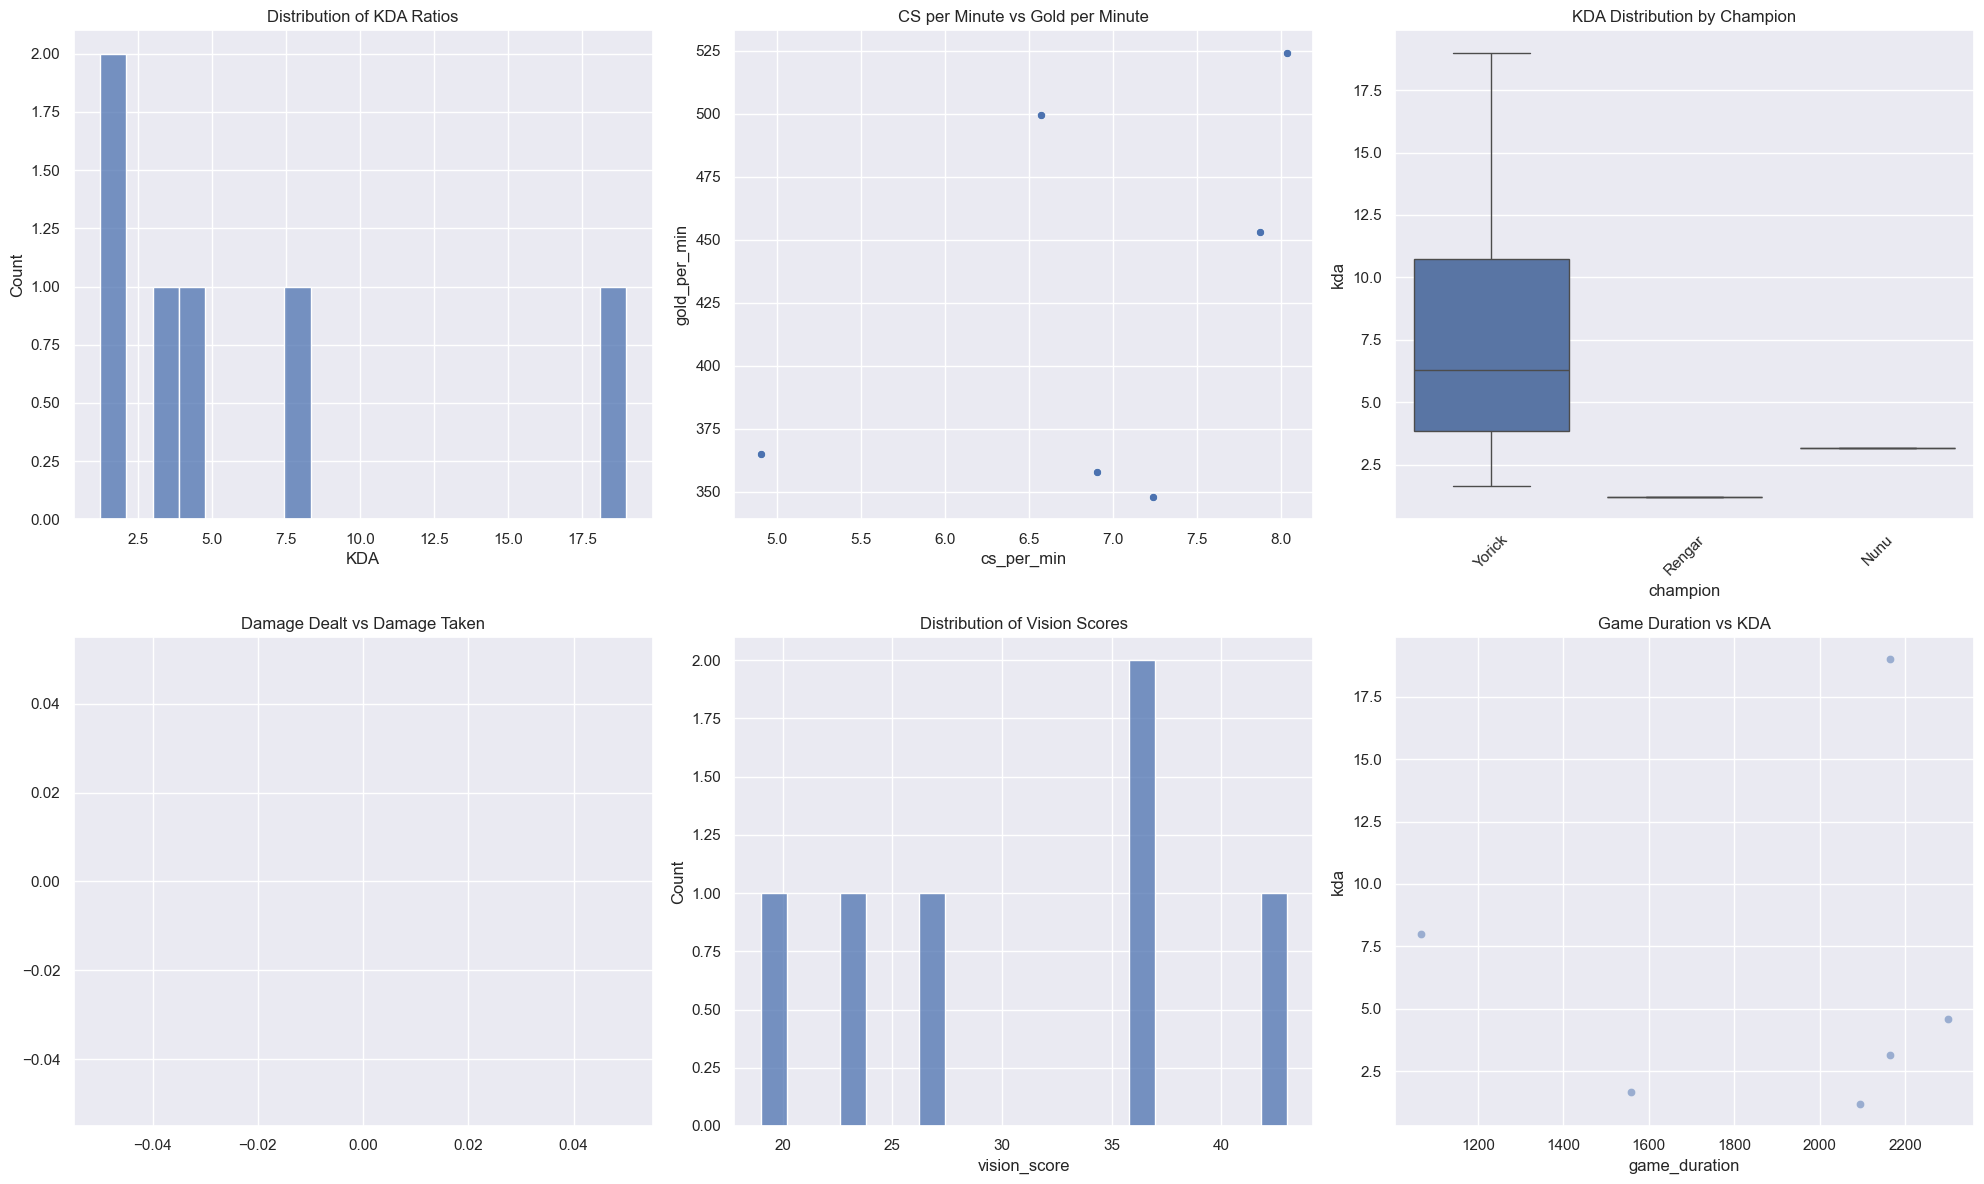

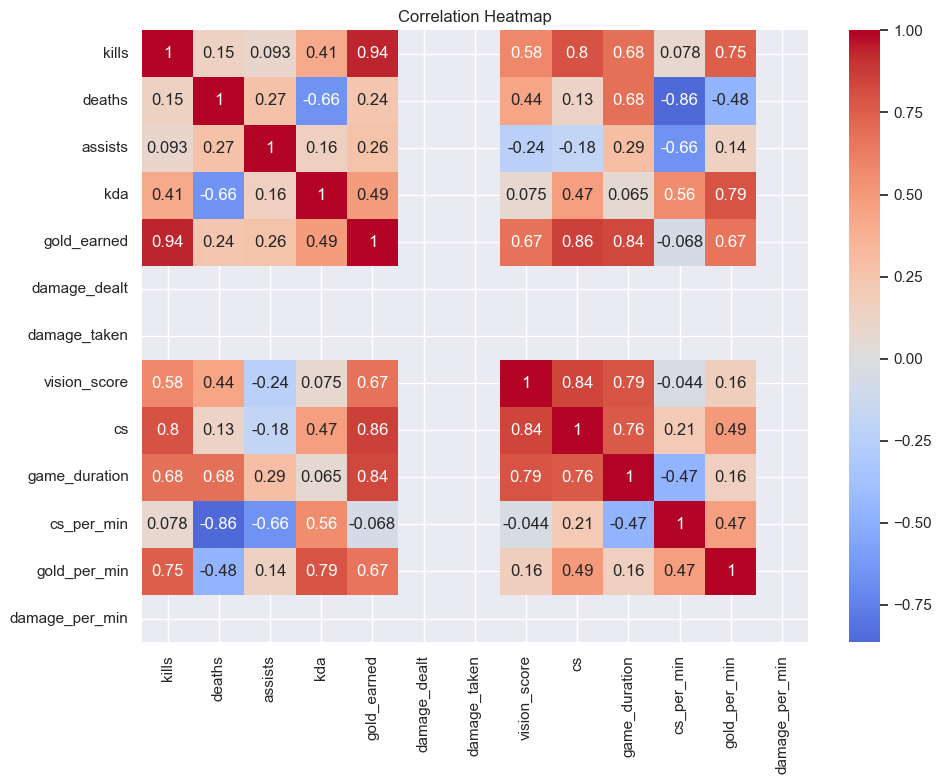

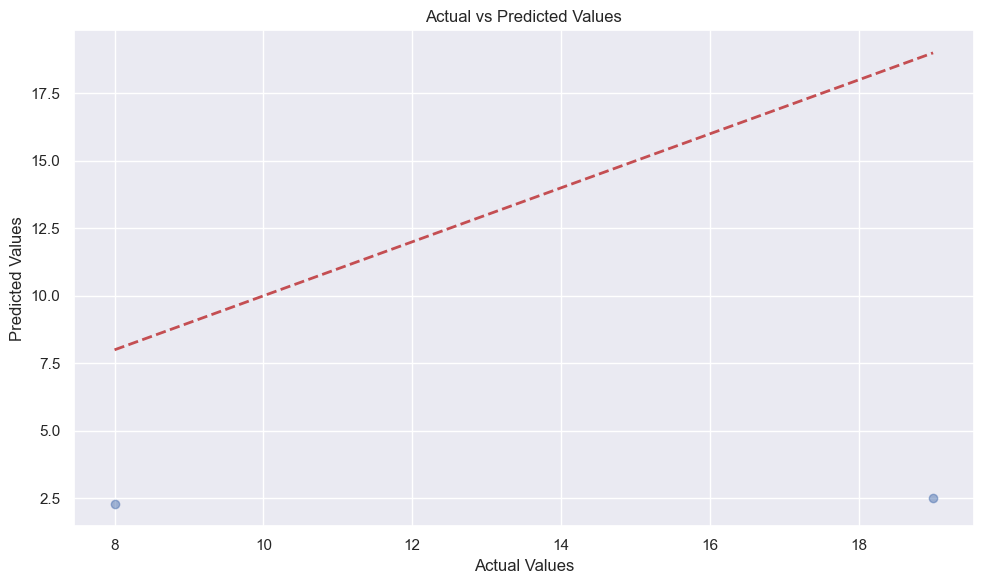

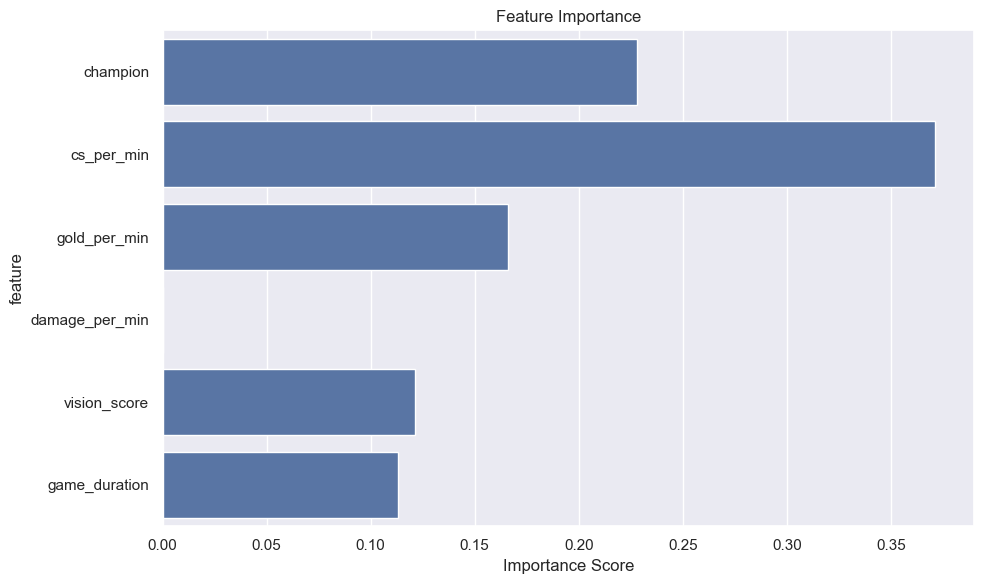

In [25]:
#display using cat and whiskers plotimport matplotlib.pyplot as plt
# Set style for better visualizations
plt.style.use('default')  # Using default style instead of seaborn
sns.set_theme()

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 12))

# 1. KDA Distribution
plt.subplot(2, 3, 1)
sns.histplot(data=df, x='kda', bins=20)
plt.title('Distribution of KDA Ratios')
plt.xlabel('KDA')
plt.ylabel('Count')

# 2. CS per Minute vs Gold per Minute
plt.subplot(2, 3, 2)
sns.scatterplot(data=df, x='cs_per_min', y='gold_per_min')
plt.title('CS per Minute vs Gold per Minute')

# 3. Champion Performance Box Plot
plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='champion', y='kda')
plt.xticks(rotation=45)
plt.title('KDA Distribution by Champion')

# 4. Damage Dealt vs Damage Taken
plt.subplot(2, 3, 4)
sns.scatterplot(data=df, x='damage_dealt', y='damage_taken', alpha=0.5)
plt.title('Damage Dealt vs Damage Taken')

# 5. Vision Score Distribution
plt.subplot(2, 3, 5)
sns.histplot(data=df, x='vision_score', bins=20)
plt.title('Distribution of Vision Scores')

# 6. Game Duration vs KDA
plt.subplot(2, 3, 6)
sns.scatterplot(data=df, x='game_duration', y='kda', alpha=0.5)
plt.title('Game Duration vs KDA')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# If you have model predictions, visualize actual vs predicted values
if 'y_test' in locals() and 'y_pred' in locals():
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.tight_layout()
    plt.show()

# Feature Importance Plot (if you have a trained model)
if 'feature_importance' in locals():
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature')
    plt.title('Feature Importance')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()